# Energy Efficiency Dataset - Data Collection and Preprocessing


**Features:**
- X1: Relative Compactness
- X2: Surface Area
- X3: Wall Area
- X4: Roof Area
- X5: Overall Height
- X6: Orientation
- X7: Glazing Area
- X8: Glazing Area Distribution

**Targets:**
- Y1: Heating Load
- Y2: Cooling Load

In [163]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# UCI ML Repository
from ucimlrepo import fetch_ucirepo

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


Fetch Dataset from UCI ML Repository

In [164]:
# Fetch the Energy Efficiency dataset
energy_efficiency = fetch_ucirepo(id=242)

# Extract features and targets
X = energy_efficiency.data.features
y = energy_efficiency.data.targets

print("Dataset fetched successfully!")
print(f"\nFeatures shape: {X.shape}")
print(f"Targets shape: {y.shape}")

Dataset fetched successfully!

Features shape: (768, 8)
Targets shape: (768, 2)


## Combine Features and Targets into Single DataFrame

In [166]:
# Combine features and targets
df = pd.concat([X, y], axis=1)

# Rename columns to more descriptive names
column_mapping = {
    'X1': 'Relative_Compactness',
    'X2': 'Surface_Area',
    'X3': 'Wall_Area',
    'X4': 'Roof_Area',
    'X5': 'Overall_Height',
    'X6': 'Orientation',
    'X7': 'Glazing_Area',
    'X8': 'Glazing_Area_Distribution',
    'Y1': 'Heating_Load',
    'Y2': 'Cooling_Load'
}

df = df.rename(columns=column_mapping)

print(f"Combined dataset shape: {df.shape}")
print(f"\nColumn names:\n{df.columns.tolist()}")

Combined dataset shape: (768, 10)

Column names:
['Relative_Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area', 'Overall_Height', 'Orientation', 'Glazing_Area', 'Glazing_Area_Distribution', 'Heating_Load', 'Cooling_Load']


## Initial Data Exploration

In [167]:
# Display first few rows
print("First 10 rows of the dataset:")
display(df.head(10))

First 10 rows of the dataset:


,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
0,0.9800,514.5000,294.0000,110.2500,7.0000,2,0.0000,0,15.5500,21.3300
1,0.9800,514.5000,294.0000,110.2500,7.0000,3,0.0000,0,15.5500,21.3300
2,0.9800,514.5000,294.0000,110.2500,7.0000,4,0.0000,0,15.5500,21.3300
3,0.9800,514.5000,294.0000,110.2500,7.0000,5,0.0000,0,15.5500,21.3300
4,0.9000,563.5000,318.5000,122.5000,7.0000,2,0.0000,0,20.8400,28.2800
5,0.9000,563.5000,318.5000,122.5000,7.0000,3,0.0000,0,21.4600,25.3800
6,0.9000,563.5000,318.5000,122.5000,7.0000,4,0.0000,0,20.7100,25.1600
7,0.9000,563.5000,318.5000,122.5000,7.0000,5,0.0000,0,19.6800,29.6000
8,0.8600,588.0000,294.0000,147.0000,7.0000,2,0.0000,0,19.5000,27.3000
9,0.8600,588.0000,294.0000,147.0000,7.0000,3,0.0000,0,19.9500,21.9700


In [168]:
# Display last few rows
print("Last 10 rows of the dataset:")
display(df.tail(10))

Last 10 rows of the dataset:


,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
758,0.6600,759.5000,318.5000,220.5000,3.5000,4,0.4000,5,14.9200,17.5500
759,0.6600,759.5000,318.5000,220.5000,3.5000,5,0.4000,5,15.1600,18.0600
760,0.6400,784.0000,343.0000,220.5000,3.5000,2,0.4000,5,17.6900,20.8200
761,0.6400,784.0000,343.0000,220.5000,3.5000,3,0.4000,5,18.1900,20.2100
762,0.6400,784.0000,343.0000,220.5000,3.5000,4,0.4000,5,18.1600,20.7100
763,0.6400,784.0000,343.0000,220.5000,3.5000,5,0.4000,5,17.8800,21.4000
764,0.6200,808.5000,367.5000,220.5000,3.5000,2,0.4000,5,16.5400,16.8800
765,0.6200,808.5000,367.5000,220.5000,3.5000,3,0.4000,5,16.4400,17.1100
766,0.6200,808.5000,367.5000,220.5000,3.5000,4,0.4000,5,16.4800,16.6100
767,0.6200,808.5000,367.5000,220.5000,3.5000,5,0.4000,5,16.6400,16.0300


In [170]:
# Display summary statistics
print("Summary Statistics:")
display(df.describe())

Summary Statistics:


,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
count,768.0000,768.0000,768.0000,768.0000,768.0000,768.0000,768.0000,768.0000,768.0000,768.0000
mean,0.7642,671.7083,318.5000,176.6042,5.2500,3.5000,0.2344,2.8125,22.3072,24.5878
std,0.1058,88.0861,43.6265,45.1660,1.7511,1.1188,0.1332,1.5510,10.0902,9.5133
min,0.6200,514.5000,245.0000,110.2500,3.5000,2.0000,0.0000,0.0000,6.0100,10.9000
25%,0.6825,606.3750,294.0000,140.8750,3.5000,2.7500,0.1000,1.7500,12.9925,15.6200
50%,0.7500,673.7500,318.5000,183.7500,5.2500,3.5000,0.2500,3.0000,18.9500,22.0800
75%,0.8300,741.1250,343.0000,220.5000,7.0000,4.2500,0.4000,4.0000,31.6675,33.1325
max,0.9800,808.5000,416.5000,220.5000,7.0000,5.0000,0.4000,5.0000,43.1000,48.0300


In [171]:
# Check for missing values
print("Missing Values:")
missing_values = df.isnull().sum()
print(missing_values)
print(f"\nTotal missing values: {missing_values.sum()}")

Missing Values:
Relative_Compactness         0
Surface_Area                 0
Wall_Area                    0
Roof_Area                    0
Overall_Height               0
Orientation                  0
Glazing_Area                 0
Glazing_Area_Distribution    0
Heating_Load                 0
Cooling_Load                 0
dtype: int64

Total missing values: 0


In [172]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

if duplicates > 0:
    print("\nDuplicate rows:")
    display(df[df.duplicated(keep=False)].sort_values(by=list(df.columns)))

Number of duplicate rows: 0


## Distribution Analysis

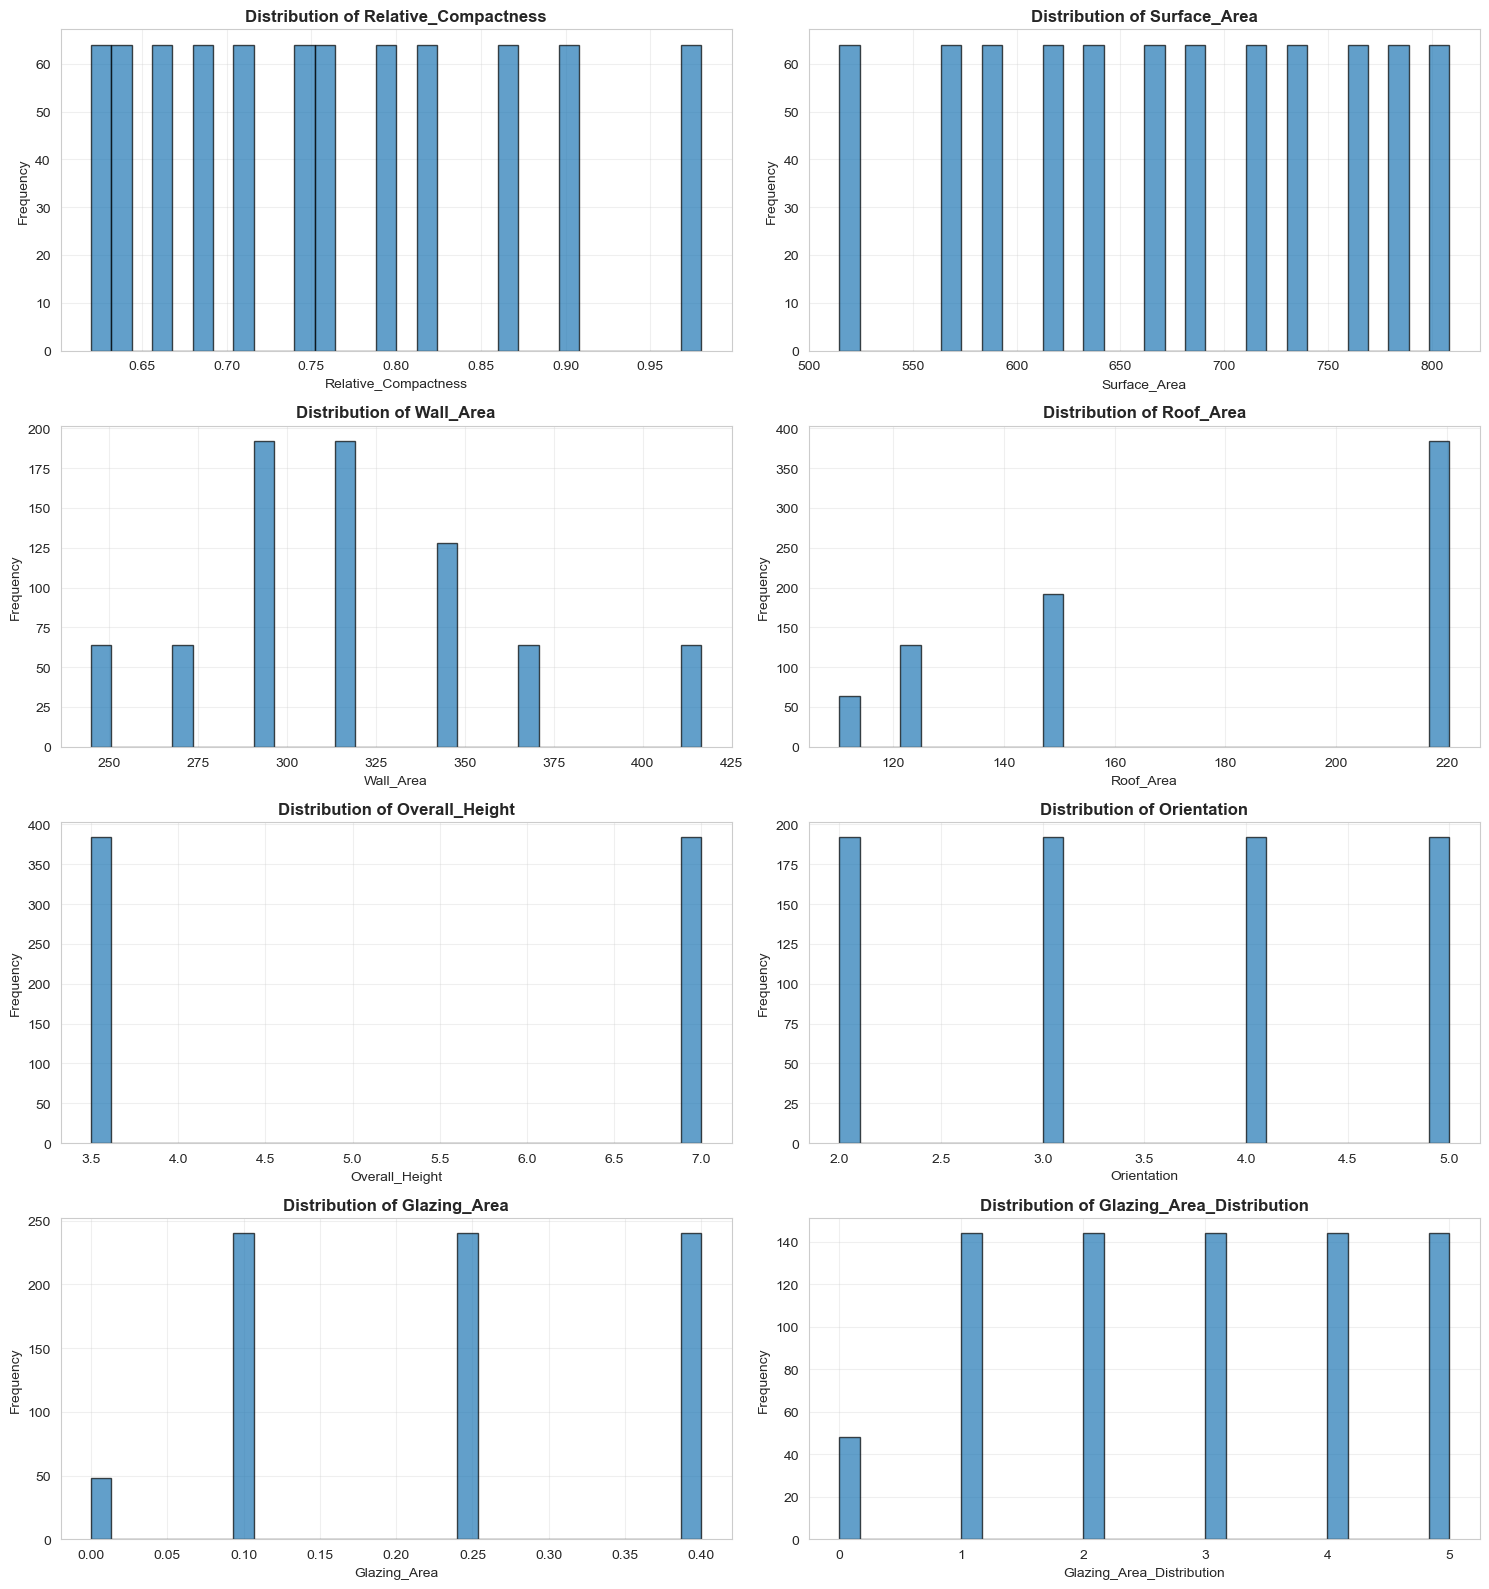

In [174]:
# Plot distributions of all features
fig, axes = plt.subplots(4, 2, figsize=(15, 16))
axes = axes.ravel()

feature_cols = df.columns[:-2]  # Exclude targets

for idx, col in enumerate(feature_cols):
    axes[idx].hist(df[col], bins=30, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

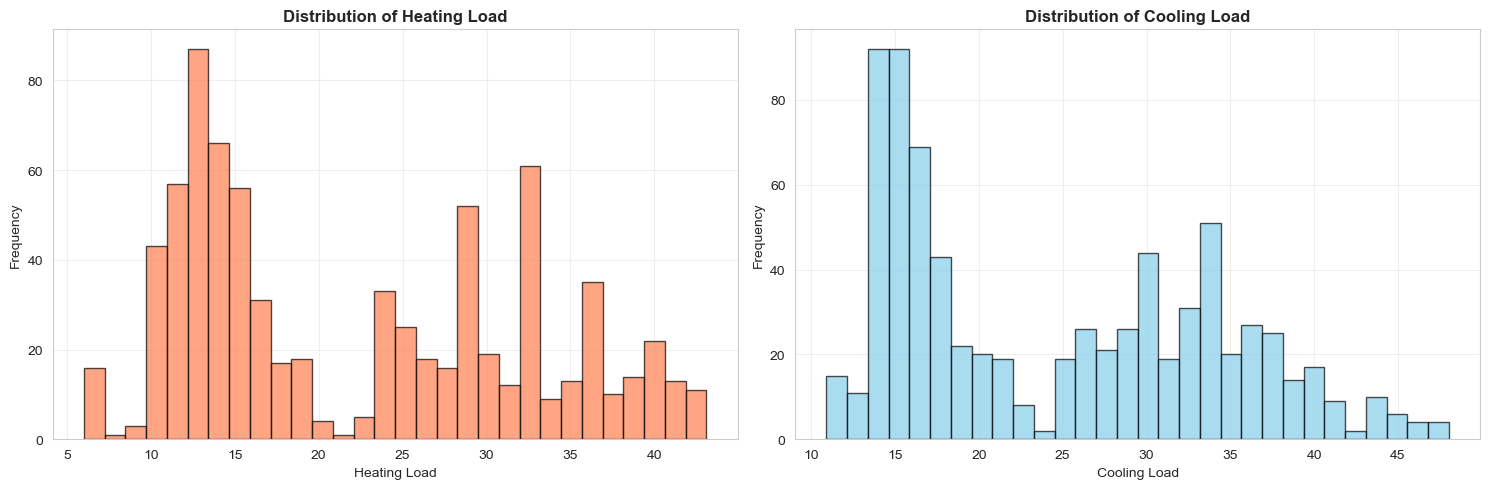

In [175]:
# Plot distributions of target variables
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(df['Heating_Load'], bins=30, edgecolor='black', alpha=0.7, color='coral')
axes[0].set_title('Distribution of Heating Load', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Heating Load')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, alpha=0.3)

axes[1].hist(df['Cooling_Load'], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
axes[1].set_title('Distribution of Cooling Load', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Cooling Load')
axes[1].set_ylabel('Frequency')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Correlation Analysis

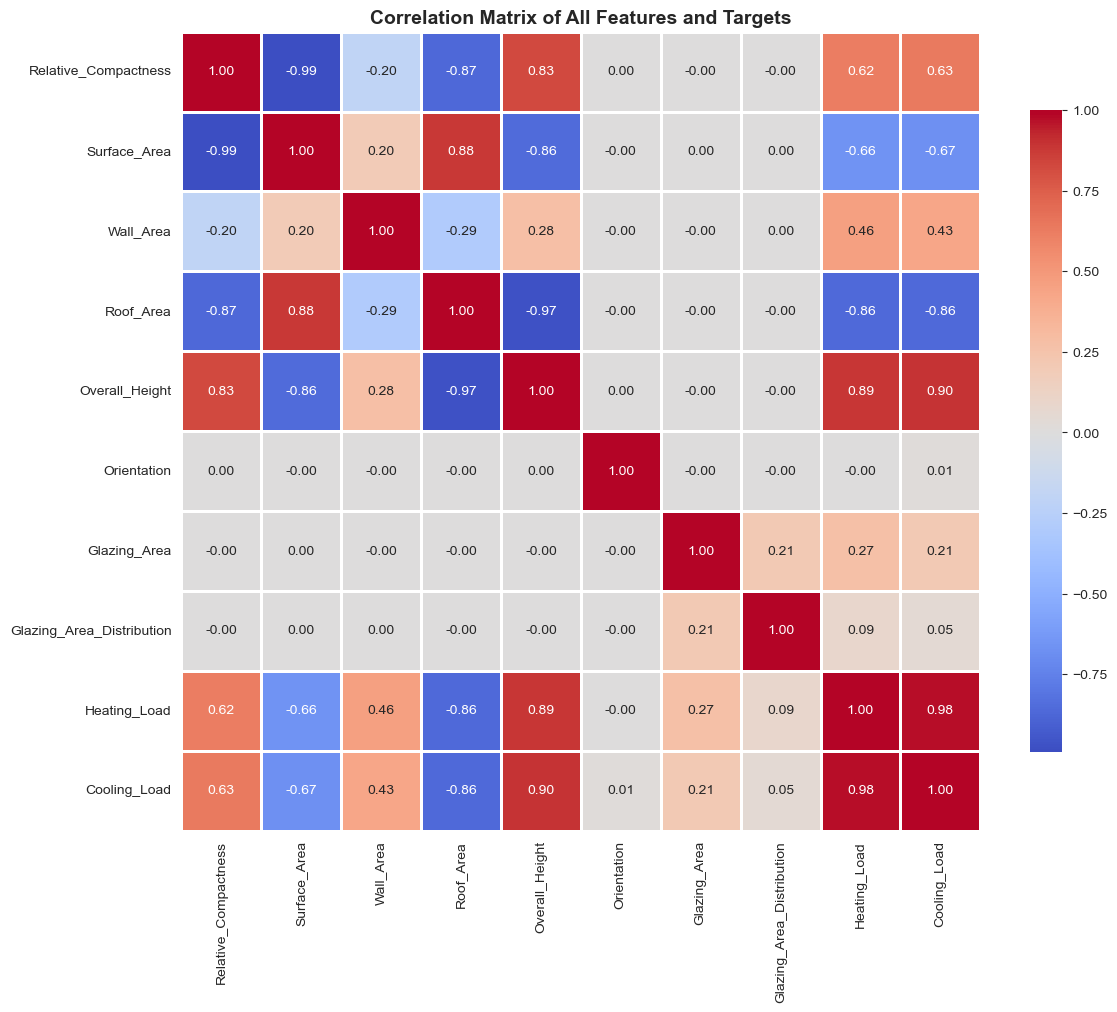

In [176]:
# Compute correlation matrix
correlation_matrix = df.corr()

# Plot correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of All Features and Targets', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [177]:
# Display correlations with target variables
print("Correlations with Heating Load:")
heating_corr = correlation_matrix['Heating_Load'].sort_values(ascending=False)
print(heating_corr)

print("\n" + "="*50 + "\n")

print("Correlations with Cooling Load:")
cooling_corr = correlation_matrix['Cooling_Load'].sort_values(ascending=False)
print(cooling_corr)

Correlations with Heating Load:
Heating_Load                 1.0000
Cooling_Load                 0.9759
Overall_Height               0.8894
Relative_Compactness         0.6223
Wall_Area                    0.4557
Glazing_Area                 0.2698
Glazing_Area_Distribution    0.0874
Orientation                 -0.0026
Surface_Area                -0.6581
Roof_Area                   -0.8618
Name: Heating_Load, dtype: float64


Correlations with Cooling Load:
Cooling_Load                 1.0000
Heating_Load                 0.9759
Overall_Height               0.8958
Relative_Compactness         0.6343
Wall_Area                    0.4271
Glazing_Area                 0.2075
Glazing_Area_Distribution    0.0505
Orientation                  0.0143
Surface_Area                -0.6730
Roof_Area                   -0.8625
Name: Cooling_Load, dtype: float64


## Comprehensive Feature Impact Analysis

### Understanding Which Building Parameters Affect Energy Use

This section analyzes how each of the 8 building features (X1-X8) correlates with and impacts:
- **Heating Load (Y1)**: Energy needed to heat the building
- **Cooling Load (Y2)**: Energy needed to cool the building

We'll identify which structural and design parameters have the strongest influence on energy efficiency.

In [178]:
# Create comprehensive feature impact comparison
print("=" * 90)
print("FEATURE CORRELATIONS WITH HEATING AND COOLING LOADS")
print("=" * 90)

# Get feature correlations (excluding the targets themselves)
feature_names = df.columns[:-2]
heating_feat_corr = heating_corr[feature_names].sort_values(ascending=False, key=abs)
cooling_feat_corr = cooling_corr[feature_names].sort_values(ascending=False, key=abs)

# Create comparison DataFrame
impact_df = pd.DataFrame({
    'Feature': feature_names,
    'Heating_Load_Corr': [heating_corr[f] for f in feature_names],
    'Cooling_Load_Corr': [cooling_corr[f] for f in feature_names],
})
impact_df['Avg_Abs_Corr'] = (impact_df['Heating_Load_Corr'].abs() + impact_df['Cooling_Load_Corr'].abs()) / 2
impact_df = impact_df.sort_values('Avg_Abs_Corr', ascending=False)

print("\nRanked by Average Absolute Correlation:\n")
for idx, row in impact_df.iterrows():
    print(f"{row['Feature']:30s} | Heating: {row['Heating_Load_Corr']:+.4f} | Cooling: {row['Cooling_Load_Corr']:+.4f} | Avg: {row['Avg_Abs_Corr']:.4f}")

print("\n" + "=" * 90)
print("KEY INSIGHTS:")
print("=" * 90)
print(f"• Top feature for Heating: {heating_feat_corr.index[0]} (r = {heating_feat_corr.iloc[0]:.3f})")
print(f"• Top feature for Cooling: {cooling_feat_corr.index[0]} (r = {cooling_feat_corr.iloc[0]:.3f})")
print(f"• Most impactful overall: {impact_df.iloc[0]['Feature']} (avg |r| = {impact_df.iloc[0]['Avg_Abs_Corr']:.3f})")
print("=" * 90)

FEATURE CORRELATIONS WITH HEATING AND COOLING LOADS

Ranked by Average Absolute Correlation:

Overall_Height                 | Heating: +0.8894 | Cooling: +0.8958 | Avg: 0.8926
Roof_Area                      | Heating: -0.8618 | Cooling: -0.8625 | Avg: 0.8622
Surface_Area                   | Heating: -0.6581 | Cooling: -0.6730 | Avg: 0.6656
Relative_Compactness           | Heating: +0.6223 | Cooling: +0.6343 | Avg: 0.6283
Wall_Area                      | Heating: +0.4557 | Cooling: +0.4271 | Avg: 0.4414
Glazing_Area                   | Heating: +0.2698 | Cooling: +0.2075 | Avg: 0.2387
Glazing_Area_Distribution      | Heating: +0.0874 | Cooling: +0.0505 | Avg: 0.0689
Orientation                    | Heating: -0.0026 | Cooling: +0.0143 | Avg: 0.0084

KEY INSIGHTS:
• Top feature for Heating: Overall_Height (r = 0.889)
• Top feature for Cooling: Overall_Height (r = 0.896)
• Most impactful overall: Overall_Height (avg |r| = 0.893)


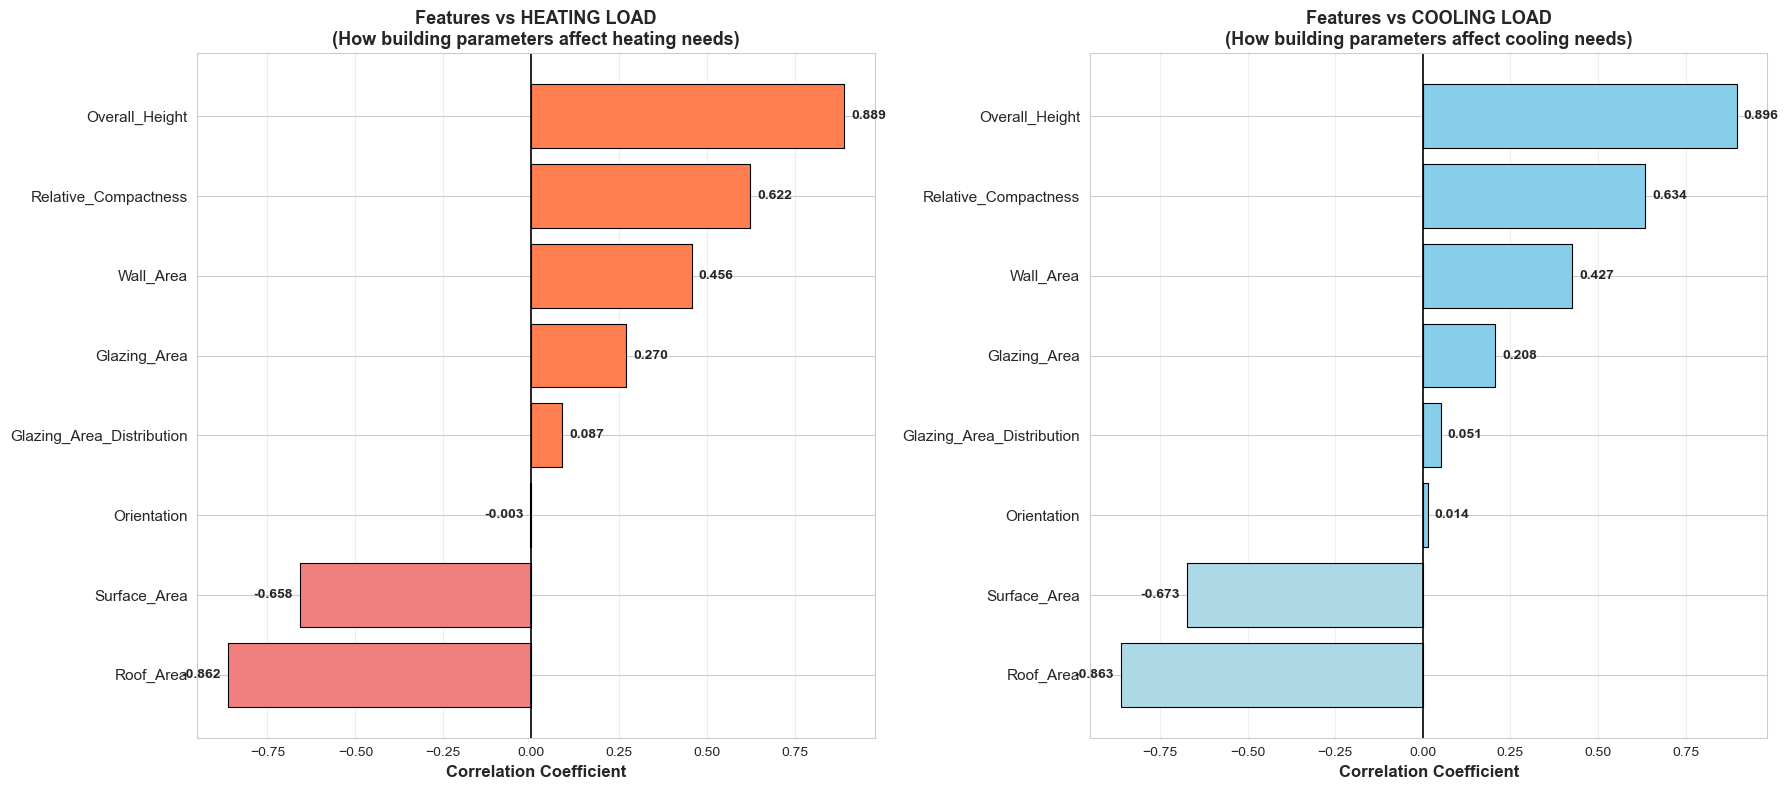

In [179]:
# Visualize feature correlations side-by-side
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Sort features by absolute correlation for better visualization
heating_sorted = heating_feat_corr.sort_values()
cooling_sorted = cooling_feat_corr.sort_values()

# Heating Load correlations
colors_heating = ['coral' if x > 0 else 'lightcoral' for x in heating_sorted.values]
axes[0].barh(range(len(heating_sorted)), heating_sorted.values, color=colors_heating, edgecolor='black', linewidth=0.8)
axes[0].set_yticks(range(len(heating_sorted)))
axes[0].set_yticklabels(heating_sorted.index, fontsize=11)
axes[0].set_xlabel('Correlation Coefficient', fontsize=12, fontweight='bold')
axes[0].set_title('Features vs HEATING LOAD\n(How building parameters affect heating needs)', 
                  fontsize=13, fontweight='bold')
axes[0].axvline(x=0, color='black', linestyle='-', linewidth=1.2)
axes[0].grid(True, alpha=0.3, axis='x')
for i, v in enumerate(heating_sorted.values):
    axes[0].text(v + 0.02 if v > 0 else v - 0.02, i, f'{v:.3f}', 
                va='center', ha='left' if v > 0 else 'right', fontsize=10, fontweight='bold')

# Cooling Load correlations
colors_cooling = ['skyblue' if x > 0 else 'lightblue' for x in cooling_sorted.values]
axes[1].barh(range(len(cooling_sorted)), cooling_sorted.values, color=colors_cooling, edgecolor='black', linewidth=0.8)
axes[1].set_yticks(range(len(cooling_sorted)))
axes[1].set_yticklabels(cooling_sorted.index, fontsize=11)
axes[1].set_xlabel('Correlation Coefficient', fontsize=12, fontweight='bold')
axes[1].set_title('Features vs COOLING LOAD\n(How building parameters affect cooling needs)', 
                  fontsize=13, fontweight='bold')
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=1.2)
axes[1].grid(True, alpha=0.3, axis='x')
for i, v in enumerate(cooling_sorted.values):
    axes[1].text(v + 0.02 if v > 0 else v - 0.02, i, f'{v:.3f}', 
                va='center', ha='left' if v > 0 else 'right', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

##  Feature-Target Relationships

### ALL 8 Features vs Heating Load

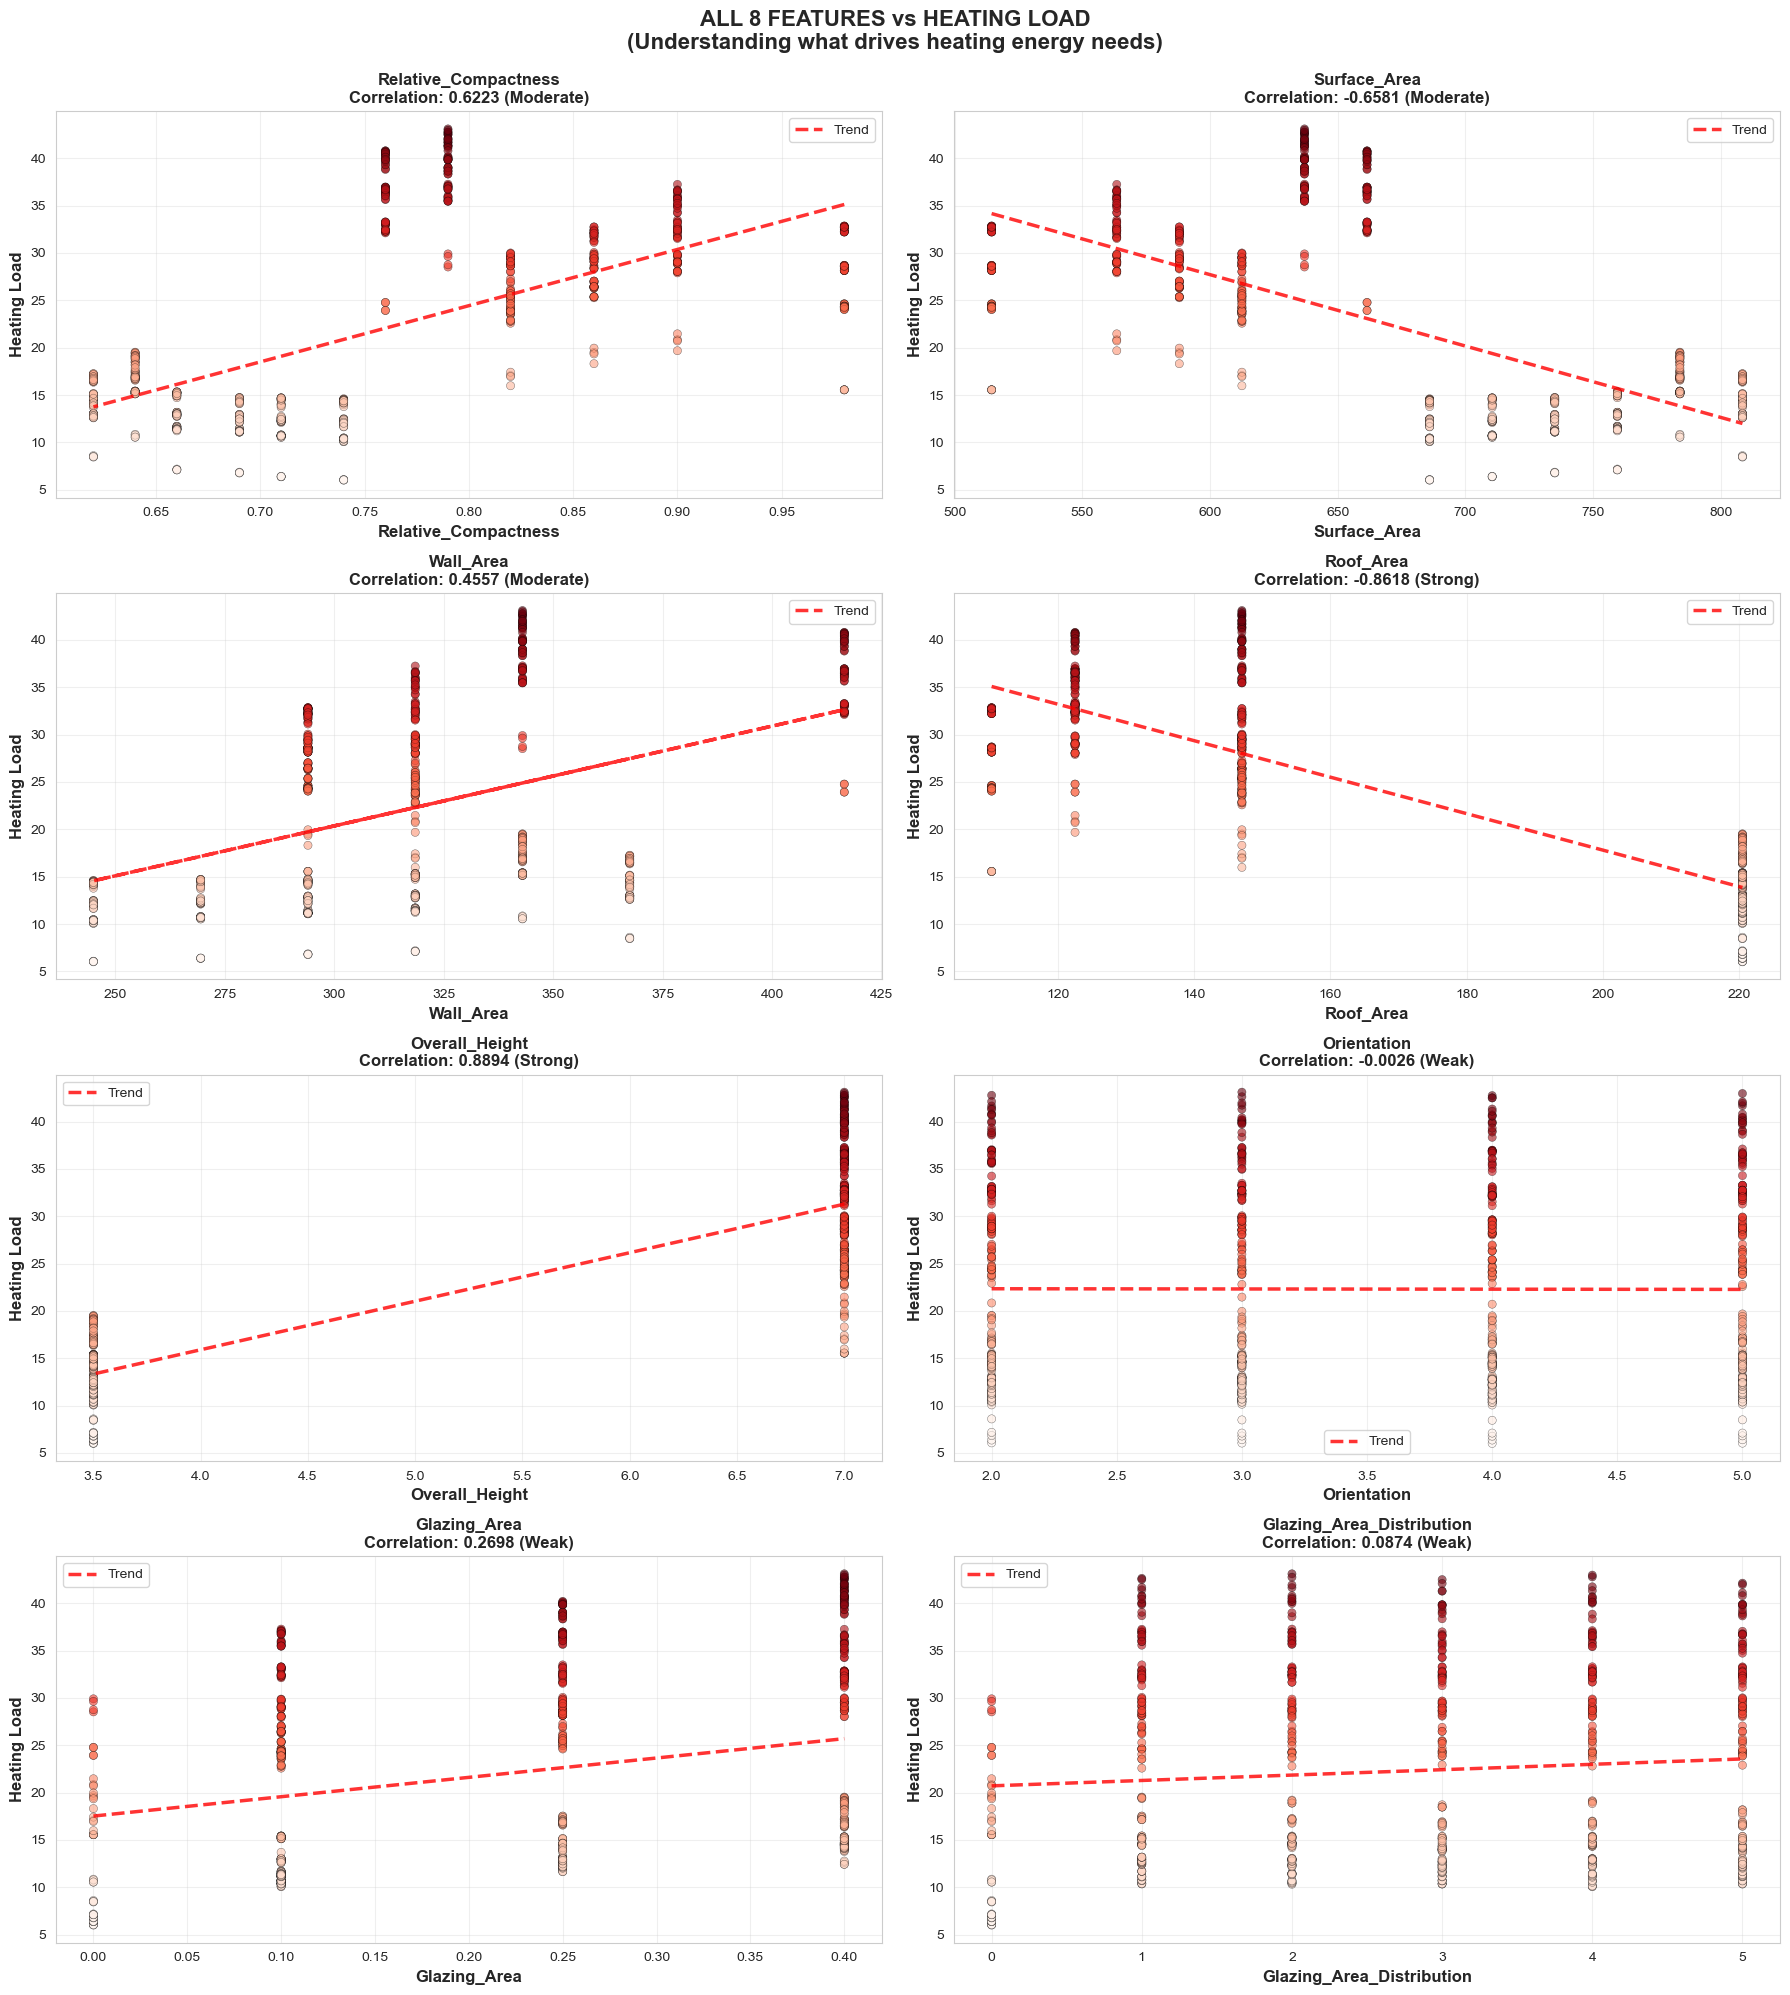

In [180]:
# Create comprehensive scatter plots: ALL features vs Heating Load
fig, axes = plt.subplots(4, 2, figsize=(18, 20))
axes = axes.ravel()

feature_names = df.columns[:-2]
for idx, feature in enumerate(feature_names):
    corr_val = heating_corr[feature]
    
    # Scatter plot
    axes[idx].scatter(df[feature], df['Heating_Load'], alpha=0.6, s=35, 
                     c=df['Heating_Load'], cmap='Reds', edgecolors='black', linewidth=0.3)
    
    # Add trend line
    z = np.polyfit(df[feature], df['Heating_Load'], 1)
    p = np.poly1d(z)
    axes[idx].plot(df[feature], p(df[feature]), "r--", alpha=0.8, linewidth=2.5, label='Trend')
    
    axes[idx].set_xlabel(feature, fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Heating Load', fontsize=12, fontweight='bold')
    axes[idx].set_title(f'{feature}\nCorrelation: {corr_val:.4f} {"(Strong)" if abs(corr_val) > 0.7 else "(Moderate)" if abs(corr_val) > 0.4 else "(Weak)"}', 
                       fontsize=12, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend(loc='best')

plt.suptitle('ALL 8 FEATURES vs HEATING LOAD\n(Understanding what drives heating energy needs)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

### ALL 8 Features vs Cooling Load

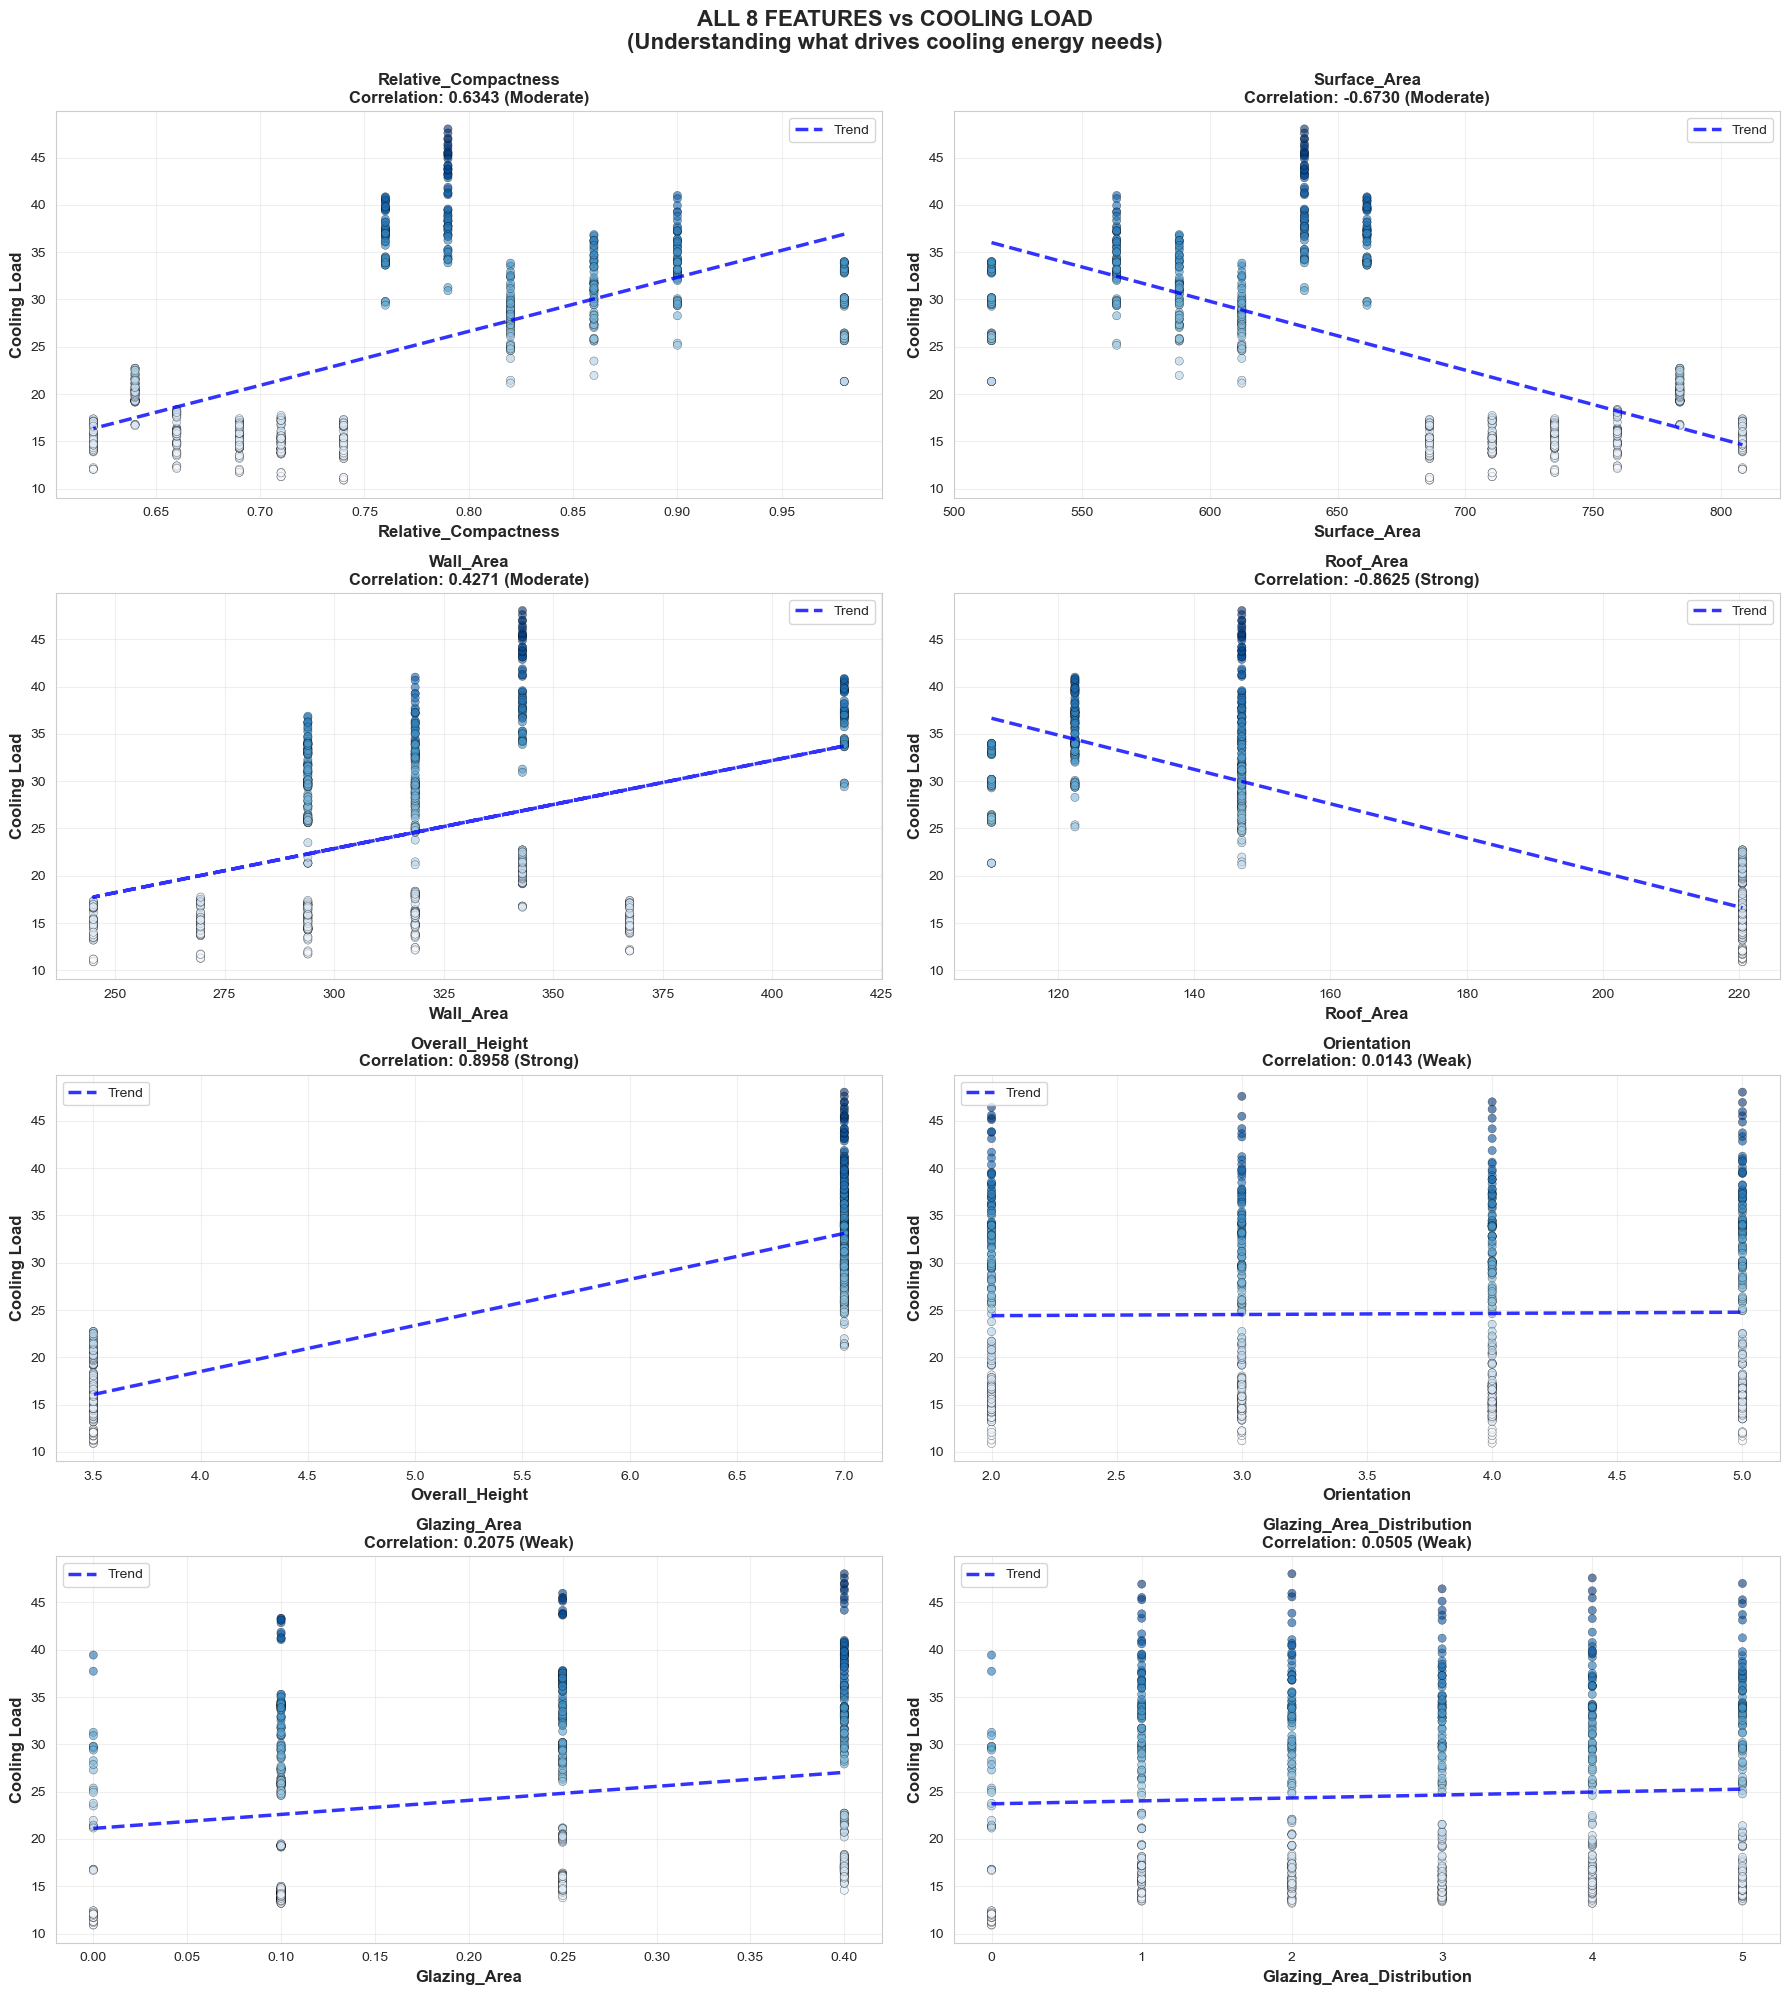

In [181]:
# Create comprehensive scatter plots: ALL features vs Cooling Load
fig, axes = plt.subplots(4, 2, figsize=(18, 20))
axes = axes.ravel()

feature_names = df.columns[:-2]
for idx, feature in enumerate(feature_names):
    corr_val = cooling_corr[feature]
    
    # Scatter plot
    axes[idx].scatter(df[feature], df['Cooling_Load'], alpha=0.6, s=35, 
                     c=df['Cooling_Load'], cmap='Blues', edgecolors='black', linewidth=0.3)
    
    # Add trend line
    z = np.polyfit(df[feature], df['Cooling_Load'], 1)
    p = np.poly1d(z)
    axes[idx].plot(df[feature], p(df[feature]), "b--", alpha=0.8, linewidth=2.5, label='Trend')
    
    axes[idx].set_xlabel(feature, fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Cooling Load', fontsize=12, fontweight='bold')
    axes[idx].set_title(f'{feature}\nCorrelation: {corr_val:.4f} {"(Strong)" if abs(corr_val) > 0.7 else "(Moderate)" if abs(corr_val) > 0.4 else "(Weak)"}', 
                       fontsize=12, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend(loc='best')

plt.suptitle('ALL 8 FEATURES vs COOLING LOAD\n(Understanding what drives cooling energy needs)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

##  Feature Impact by Category

### Analyzing Different Types of Building Parameters

In [182]:
# Group features by category and analyze their combined impact
print("=" * 90)
print("FEATURE IMPACT BY CATEGORY")
print("=" * 90)

# Define feature categories
categories = {
    'Building Shape': ['Relative_Compactness', 'Surface_Area'],
    'Structural Elements': ['Wall_Area', 'Roof_Area', 'Overall_Height'],
    'Design Choices': ['Orientation', 'Glazing_Area', 'Glazing_Area_Distribution']
}

for category, features in categories.items():
    print(f"\n{category}:")
    print("-" * 90)
    for feature in features:
        if feature in df.columns:
            h_corr = heating_corr[feature]
            c_corr = cooling_corr[feature]
            avg_abs = (abs(h_corr) + abs(c_corr)) / 2
            print(f"  {feature:35s} | Heating: {h_corr:+.4f} | Cooling: {c_corr:+.4f} | Impact: {avg_abs:.4f}")

print("\n" + "=" * 90)

FEATURE IMPACT BY CATEGORY

Building Shape:
------------------------------------------------------------------------------------------
  Relative_Compactness                | Heating: +0.6223 | Cooling: +0.6343 | Impact: 0.6283
  Surface_Area                        | Heating: -0.6581 | Cooling: -0.6730 | Impact: 0.6656

Structural Elements:
------------------------------------------------------------------------------------------
  Wall_Area                           | Heating: +0.4557 | Cooling: +0.4271 | Impact: 0.4414
  Roof_Area                           | Heating: -0.8618 | Cooling: -0.8625 | Impact: 0.8622
  Overall_Height                      | Heating: +0.8894 | Cooling: +0.8958 | Impact: 0.8926

Design Choices:
------------------------------------------------------------------------------------------
  Orientation                         | Heating: -0.0026 | Cooling: +0.0143 | Impact: 0.0084
  Glazing_Area                        | Heating: +0.2698 | Cooling: +0.2075 | Impact: 

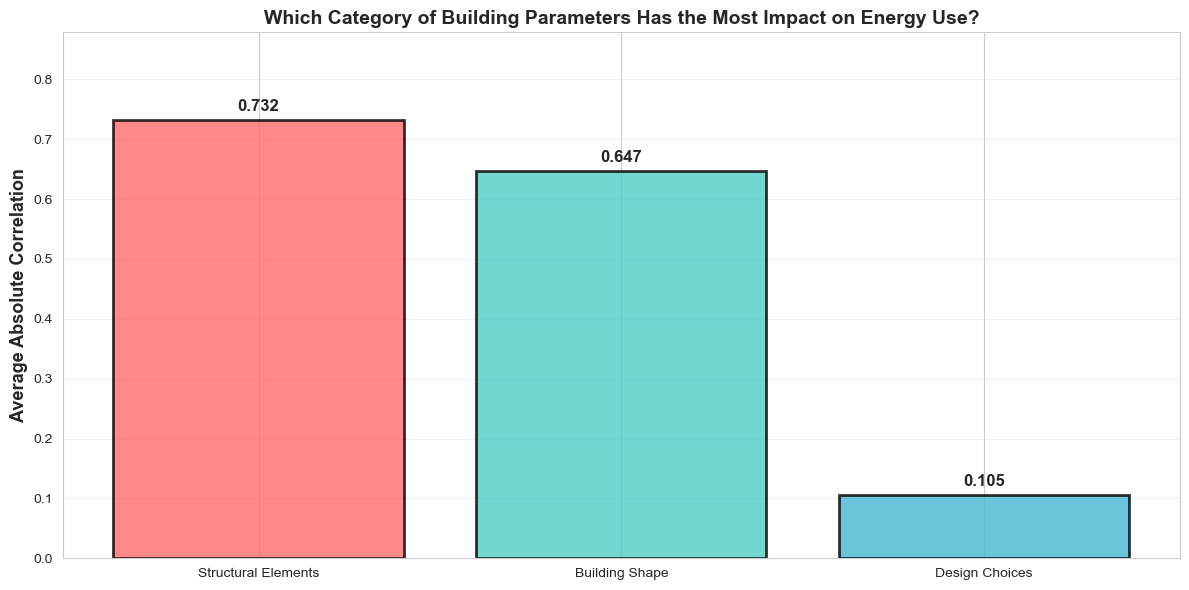

In [183]:
# Visualize impact by category
category_impact = {
    'Building Shape': [],
    'Structural Elements': [],
    'Design Choices': []
}

for category, features in categories.items():
    for feature in features:
        if feature in df.columns:
            avg_abs = (abs(heating_corr[feature]) + abs(cooling_corr[feature])) / 2
            category_impact[category].append(avg_abs)

# Calculate average impact per category
avg_category_impact = {cat: np.mean(impacts) for cat, impacts in category_impact.items()}

fig, ax = plt.subplots(1, 1, figsize=(12, 6))
categories_sorted = sorted(avg_category_impact.items(), key=lambda x: x[1], reverse=True)
cat_names = [c[0] for c in categories_sorted]
cat_values = [c[1] for c in categories_sorted]

bars = ax.bar(cat_names, cat_values, color=['#FF6B6B', '#4ECDC4', '#45B7D1'], 
              edgecolor='black', linewidth=2, alpha=0.8)
ax.set_ylabel('Average Absolute Correlation', fontsize=13, fontweight='bold')
ax.set_title('Which Category of Building Parameters Has the Most Impact on Energy Use?', 
            fontsize=14, fontweight='bold')
ax.set_ylim(0, max(cat_values) * 1.2)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, val in zip(bars, cat_values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

##  Key Findings: What Affects Energy Efficiency?

## Advanced Visualizations

### Additional insights through interactive and multi-dimensional plots

###  Feature Interaction Heatmap

Understanding correlations between features (multicollinearity check)

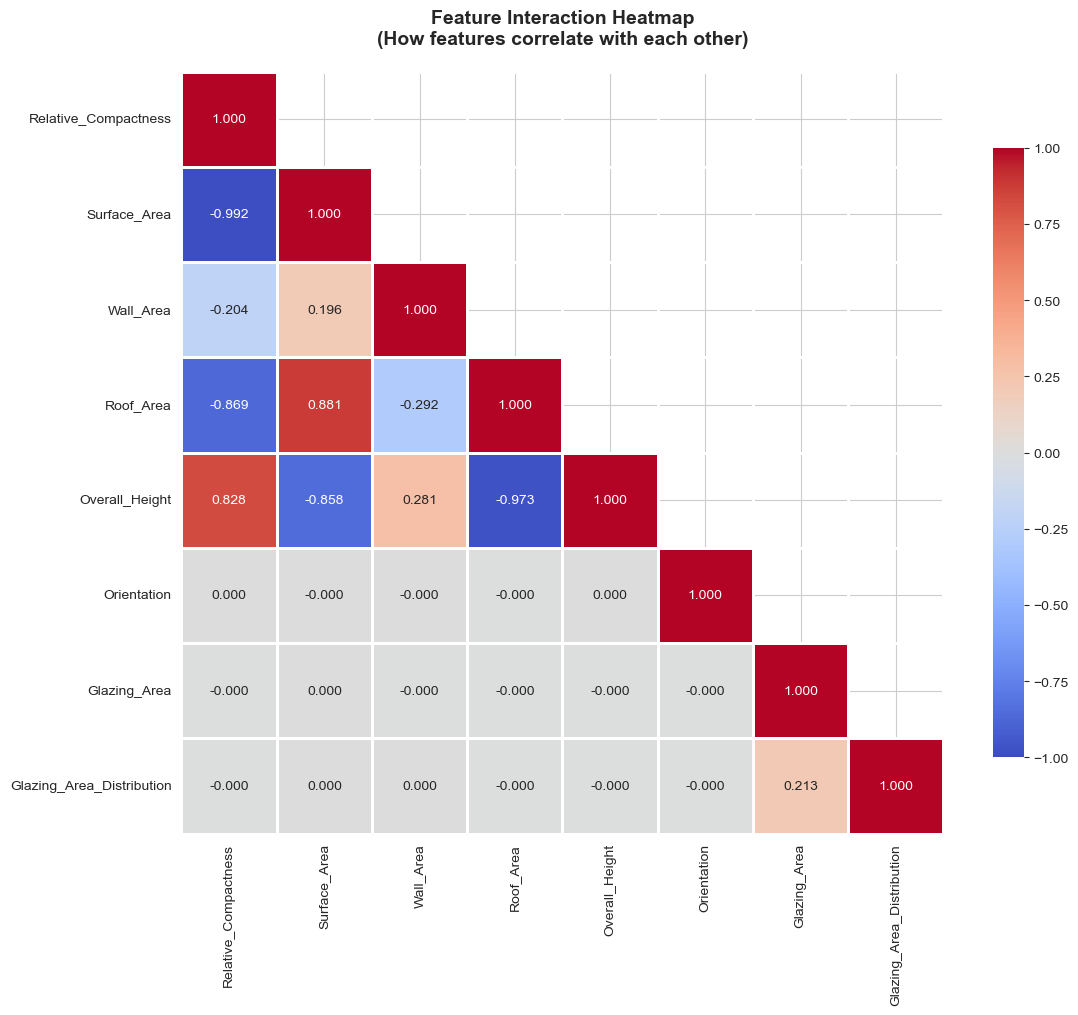


🔍 MULTICOLLINEARITY INSIGHTS:
Highly correlated feature pairs (|r| > 0.7):
  • Relative_Compactness ↔ Surface_Area: -0.992
  • Roof_Area ↔ Overall_Height: -0.973
  • Surface_Area ↔ Roof_Area: +0.881
  • Relative_Compactness ↔ Roof_Area: -0.869
  • Surface_Area ↔ Overall_Height: -0.858
  • Relative_Compactness ↔ Overall_Height: +0.828

⚠️  These features may provide redundant information in modeling.


In [ ]:
# Feature-to-feature correlation heatmap (checking for multicollinearity)
feature_corr = df[df.columns[:-2]].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(feature_corr, dtype=bool), k=1)  # Mask upper triangle

sns.heatmap(feature_corr, mask=mask, annot=True, fmt='.3f', 
            cmap='coolwarm', center=0, square=True, 
            linewidths=1, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1, ax=ax)

ax.set_title('Feature Interaction Heatmap\n(How features correlate with each other)', 
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

print("\n🔍 MULTICOLLINEARITY INSIGHTS:")
print("=" * 80)
# Find highly correlated feature pairs
high_corr_pairs = []
for i in range(len(feature_corr.columns)):
    for j in range(i+1, len(feature_corr.columns)):
        if abs(feature_corr.iloc[i, j]) > 0.7:
            high_corr_pairs.append((feature_corr.columns[i], 
                                   feature_corr.columns[j], 
                                   feature_corr.iloc[i, j]))

if high_corr_pairs:
    print("Highly correlated feature pairs (|r| > 0.7):")
    for feat1, feat2, corr in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
        print(f"  • {feat1} ↔ {feat2}: {corr:+.3f}")
    print("\n These features may provide redundant information in modeling.")
else:
    print("✓ No severe multicollinearity detected (all |r| < 0.7)")
print("=" * 80)

### Compact Feature-Target Heatmap

All features vs both targets in one view

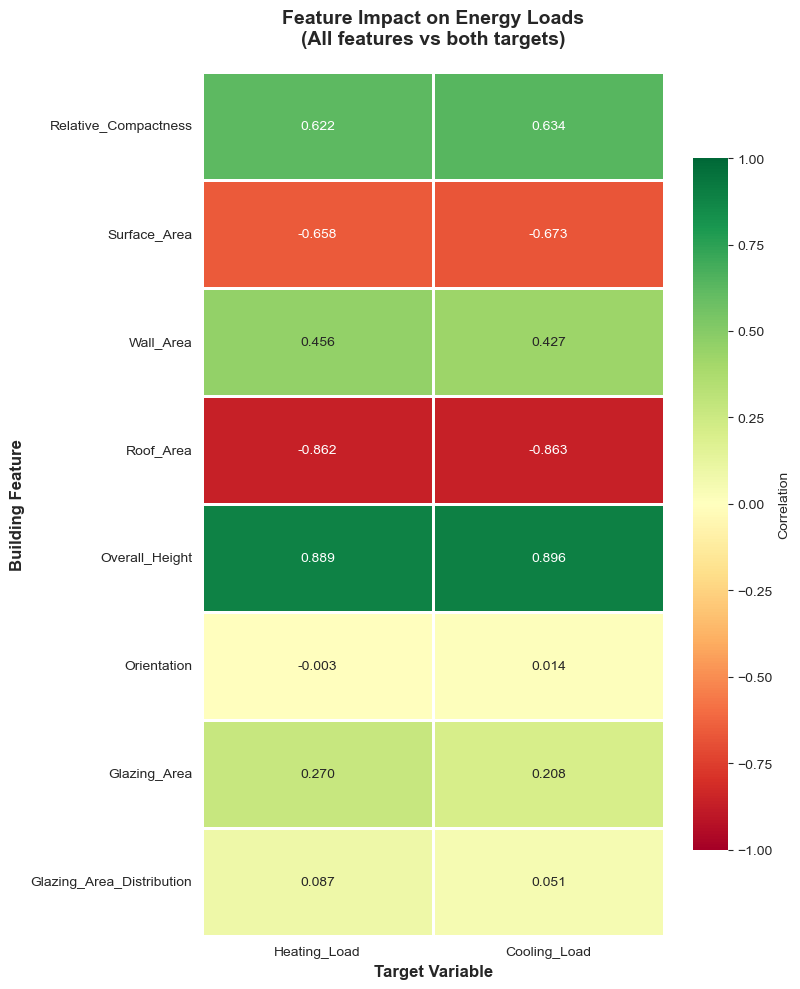

In [185]:
# Create a compact heatmap showing all features vs both targets
feature_target_corr = pd.DataFrame({
    'Heating_Load': [heating_corr[f] for f in df.columns[:-2]],
    'Cooling_Load': [cooling_corr[f] for f in df.columns[:-2]]
}, index=df.columns[:-2])

fig, ax = plt.subplots(figsize=(8, 10))
sns.heatmap(feature_target_corr, annot=True, fmt='.3f', 
            cmap='RdYlGn', center=0, linewidths=2, 
            cbar_kws={"shrink": 0.8, "label": "Correlation"},
            vmin=-1, vmax=1, ax=ax)

ax.set_title('Feature Impact on Energy Loads\n(All features vs both targets)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Target Variable', fontsize=12, fontweight='bold')
ax.set_ylabel('Building Feature', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

###  3D Scatter Plots: Multi-Feature Interactions

Visualizing how two features simultaneously affect the target

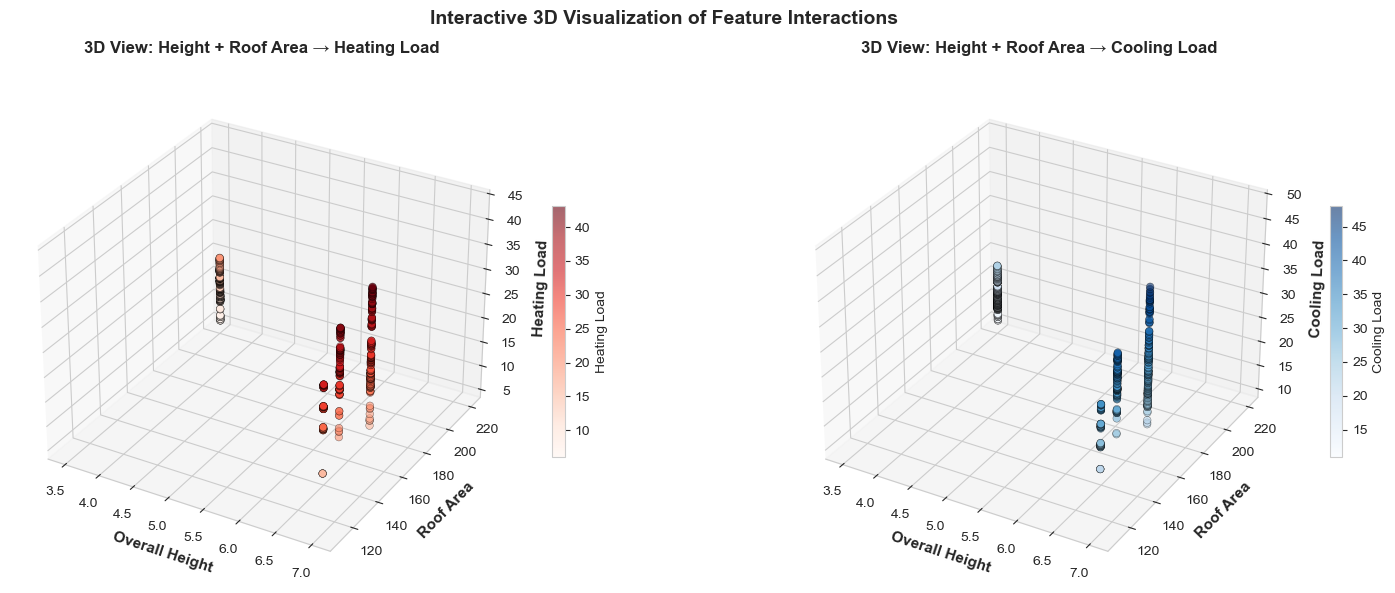


🎯 3D INSIGHTS:
• Height and Roof Area interact to determine energy loads
• Taller buildings with smaller roofs = highest energy needs
• Lower buildings with larger roofs = lowest energy needs
• The relationship is non-linear and shows clear clustering patterns


In [ ]:
# 3D scatter plot: Top 2 features + Target
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(16, 6))

# 3D plot for Heating Load
ax1 = fig.add_subplot(121, projection='3d')
scatter1 = ax1.scatter(df['Overall_Height'], df['Roof_Area'], df['Heating_Load'],
                      c=df['Heating_Load'], cmap='Reds', s=30, alpha=0.6, edgecolors='black', linewidth=0.3)
ax1.set_xlabel('Overall Height', fontsize=11, fontweight='bold')
ax1.set_ylabel('Roof Area', fontsize=11, fontweight='bold')
ax1.set_zlabel('Heating Load', fontsize=11, fontweight='bold')
ax1.set_title('3D View: Height + Roof Area → Heating Load', fontsize=12, fontweight='bold', pad=20)
fig.colorbar(scatter1, ax=ax1, shrink=0.5, label='Heating Load')

# 3D plot for Cooling Load
ax2 = fig.add_subplot(122, projection='3d')
scatter2 = ax2.scatter(df['Overall_Height'], df['Roof_Area'], df['Cooling_Load'],
                      c=df['Cooling_Load'], cmap='Blues', s=30, alpha=0.6, edgecolors='black', linewidth=0.3)
ax2.set_xlabel('Overall Height', fontsize=11, fontweight='bold')
ax2.set_ylabel('Roof Area', fontsize=11, fontweight='bold')
ax2.set_zlabel('Cooling Load', fontsize=11, fontweight='bold')
ax2.set_title('3D View: Height + Roof Area → Cooling Load', fontsize=12, fontweight='bold', pad=20)
fig.colorbar(scatter2, ax=ax2, shrink=0.5, label='Cooling Load')

plt.suptitle('Interactive 3D Visualization of Feature Interactions', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("\n3D INSIGHTS:")
print("=" * 80)
print("• Height and Roof Area interact to determine energy loads")
print("• Taller buildings with smaller roofs = highest energy needs")
print("• Lower buildings with larger roofs = lowest energy needs")
print("• The relationship is non-linear and shows clear clustering patterns")
print("=" * 80)

###  Bubble Plot: Visualizing 4 Dimensions at Once

Size and color encode additional dimensions

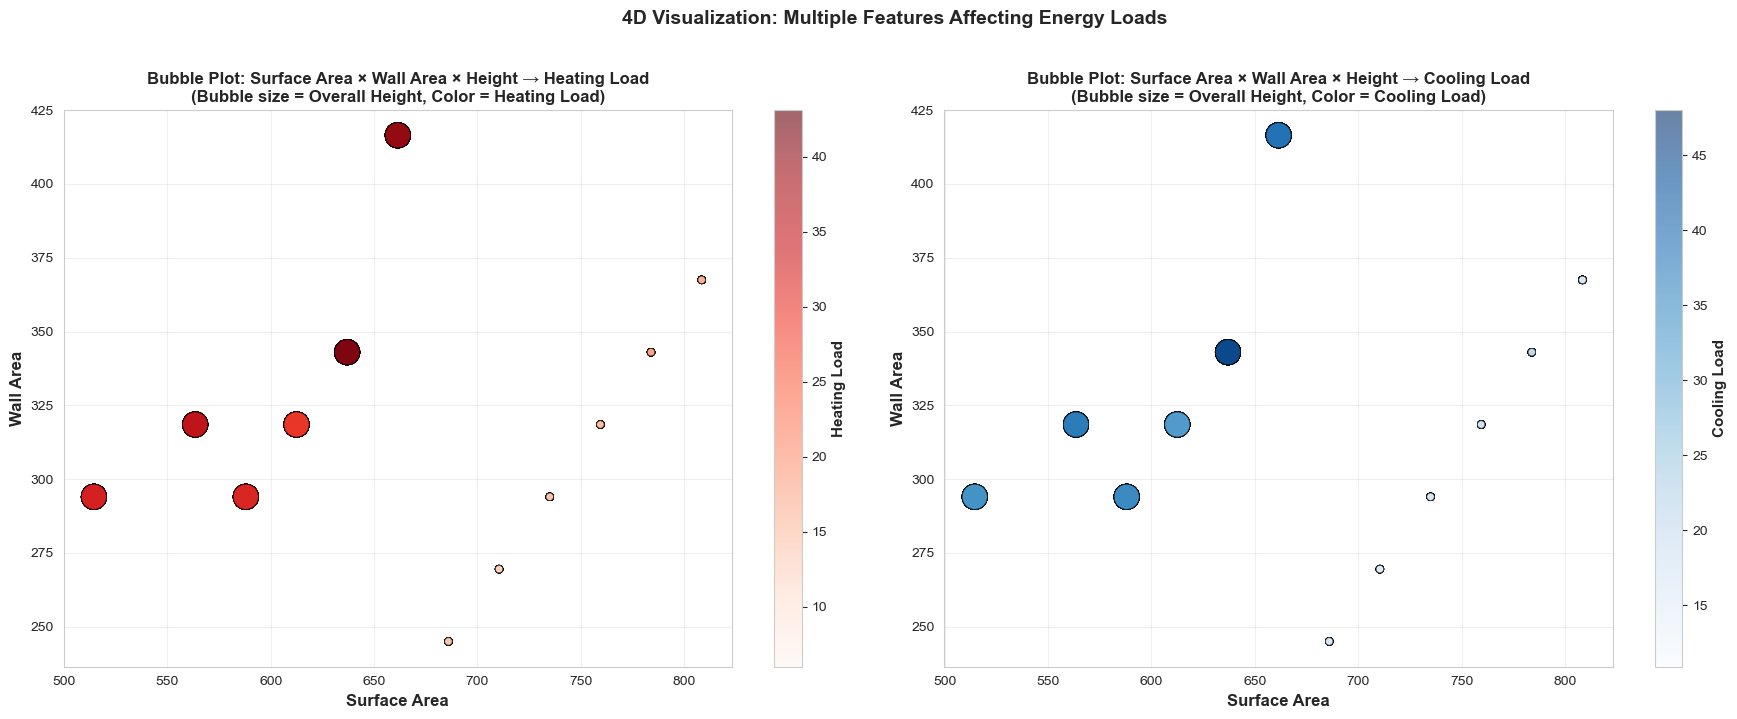


🔮 BUBBLE PLOT INSIGHTS:
• X-axis: Surface Area | Y-axis: Wall Area
• Bubble Size: Overall Height (larger = taller building)
• Color: Energy Load (darker = higher load)

Key Pattern:
• Larger bubbles (taller buildings) tend to be darker (higher loads)
• Buildings with similar surface/wall area can have very different loads
  depending on height - height is the dominant factor!


In [ ]:
# Bubble plot: 4 dimensions in one visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Normalize Overall_Height for bubble size
size_scale = (df['Overall_Height'] - df['Overall_Height'].min()) / (df['Overall_Height'].max() - df['Overall_Height'].min())
sizes = 30 + size_scale * 300  # Scale to reasonable bubble sizes

# Heating Load bubble plot
scatter1 = axes[0].scatter(df['Surface_Area'], df['Wall_Area'], 
                          s=sizes, c=df['Heating_Load'], 
                          cmap='Reds', alpha=0.6, edgecolors='black', linewidth=0.5)
axes[0].set_xlabel('Surface Area', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Wall Area', fontsize=12, fontweight='bold')
axes[0].set_title('Bubble Plot: Surface Area × Wall Area × Height → Heating Load\n(Bubble size = Overall Height, Color = Heating Load)', 
                 fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)
cbar1 = plt.colorbar(scatter1, ax=axes[0])
cbar1.set_label('Heating Load', fontsize=11, fontweight='bold')

# Cooling Load bubble plot
scatter2 = axes[1].scatter(df['Surface_Area'], df['Wall_Area'], 
                          s=sizes, c=df['Cooling_Load'], 
                          cmap='Blues', alpha=0.6, edgecolors='black', linewidth=0.5)
axes[1].set_xlabel('Surface Area', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Wall Area', fontsize=12, fontweight='bold')
axes[1].set_title('Bubble Plot: Surface Area × Wall Area × Height → Cooling Load\n(Bubble size = Overall Height, Color = Cooling Load)', 
                 fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)
cbar2 = plt.colorbar(scatter2, ax=axes[1])
cbar2.set_label('Cooling Load', fontsize=11, fontweight='bold')

plt.suptitle('4D Visualization: Multiple Features Affecting Energy Loads', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n BUBBLE PLOT INSIGHTS:")
print("=" * 80)
print("• X-axis: Surface Area | Y-axis: Wall Area")
print("• Bubble Size: Overall Height (larger = taller building)")
print("• Color: Energy Load (darker = higher load)")
print("\nKey Pattern:")
print("• Larger bubbles (taller buildings) tend to be darker (higher loads)")
print("• Buildings with similar surface/wall area can have very different loads")
print("  depending on height - height is the dominant factor!")
print("=" * 80)

###  Grouped Bar Charts: Discrete Features Comparison

Direct comparison of heating vs cooling for categorical features

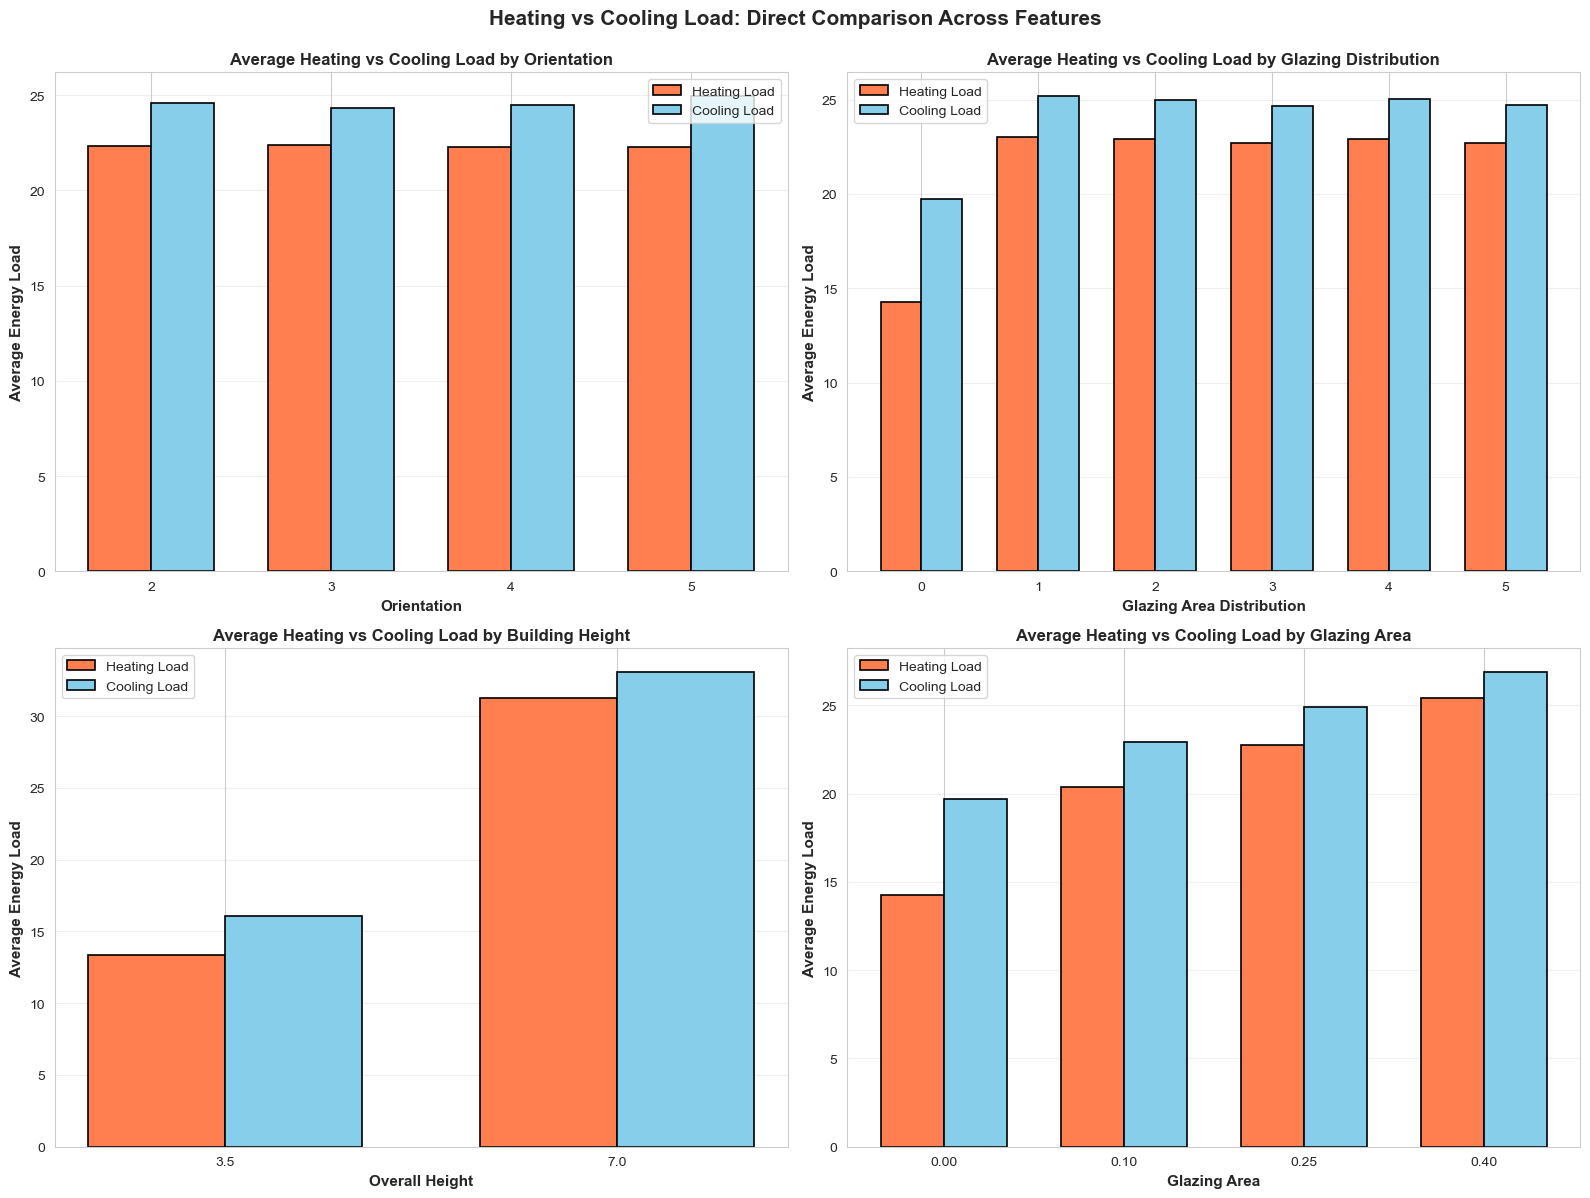


📊 COMPARATIVE INSIGHTS:
• Orientation: Minimal impact on both heating and cooling (bars nearly equal)
• Height: MASSIVE impact - taller buildings need exponentially more energy
• Glazing Area: Moderate positive relationship with energy loads
• Glazing Distribution: Some variation, but relatively minor overall

✓ Confirms our earlier finding: Height is the dominant factor!


In [ ]:
# Grouped bar charts for discrete features
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Orientation - Average Loads
orientation_stats = df.groupby('Orientation')[['Heating_Load', 'Cooling_Load']].mean()
x = np.arange(len(orientation_stats.index))
width = 0.35

axes[0, 0].bar(x - width/2, orientation_stats['Heating_Load'], width, 
               label='Heating Load', color='coral', edgecolor='black', linewidth=1.2)
axes[0, 0].bar(x + width/2, orientation_stats['Cooling_Load'], width, 
               label='Cooling Load', color='skyblue', edgecolor='black', linewidth=1.2)
axes[0, 0].set_xlabel('Orientation', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Average Energy Load', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Average Heating vs Cooling Load by Orientation', fontsize=12, fontweight='bold')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(orientation_stats.index)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Glazing Area Distribution - Average Loads
glazing_stats = df.groupby('Glazing_Area_Distribution')[['Heating_Load', 'Cooling_Load']].mean()
x2 = np.arange(len(glazing_stats.index))

axes[0, 1].bar(x2 - width/2, glazing_stats['Heating_Load'], width, 
               label='Heating Load', color='coral', edgecolor='black', linewidth=1.2)
axes[0, 1].bar(x2 + width/2, glazing_stats['Cooling_Load'], width, 
               label='Cooling Load', color='skyblue', edgecolor='black', linewidth=1.2)
axes[0, 1].set_xlabel('Glazing Area Distribution', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Average Energy Load', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Average Heating vs Cooling Load by Glazing Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xticks(x2)
axes[0, 1].set_xticklabels(glazing_stats.index)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Overall Height - Average Loads
height_stats = df.groupby('Overall_Height')[['Heating_Load', 'Cooling_Load']].mean()
x3 = np.arange(len(height_stats.index))

axes[1, 0].bar(x3 - width/2, height_stats['Heating_Load'], width, 
               label='Heating Load', color='coral', edgecolor='black', linewidth=1.2)
axes[1, 0].bar(x3 + width/2, height_stats['Cooling_Load'], width, 
               label='Cooling Load', color='skyblue', edgecolor='black', linewidth=1.2)
axes[1, 0].set_xlabel('Overall Height', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Average Energy Load', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Average Heating vs Cooling Load by Building Height', fontsize=12, fontweight='bold')
axes[1, 0].set_xticks(x3)
axes[1, 0].set_xticklabels(height_stats.index)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Glazing Area - Average Loads  
glazing_area_stats = df.groupby('Glazing_Area')[['Heating_Load', 'Cooling_Load']].mean()
x4 = np.arange(len(glazing_area_stats.index))

axes[1, 1].bar(x4 - width/2, glazing_area_stats['Heating_Load'], width, 
               label='Heating Load', color='coral', edgecolor='black', linewidth=1.2)
axes[1, 1].bar(x4 + width/2, glazing_area_stats['Cooling_Load'], width, 
               label='Cooling Load', color='skyblue', edgecolor='black', linewidth=1.2)
axes[1, 1].set_xlabel('Glazing Area', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Average Energy Load', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Average Heating vs Cooling Load by Glazing Area', fontsize=12, fontweight='bold')
axes[1, 1].set_xticks(x4)
axes[1, 1].set_xticklabels([f'{val:.2f}' for val in glazing_area_stats.index])
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Heating vs Cooling Load: Direct Comparison Across Features', 
             fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n COMPARATIVE INSIGHTS:")
print("=" * 80)
print("• Orientation: Minimal impact on both heating and cooling (bars nearly equal)")
print("• Height: MASSIVE impact - taller buildings need exponentially more energy")
print("• Glazing Area: Moderate positive relationship with energy loads")
print("• Glazing Distribution: Some variation, but relatively minor overall")
print("\n✓ Confirms our earlier finding: Height is the dominant factor!")
print("=" * 80)

##  Outlier Detection in Features

We check for outliers only in the features (X1-X8), not in the targets, as the target values are what we're trying to predict.

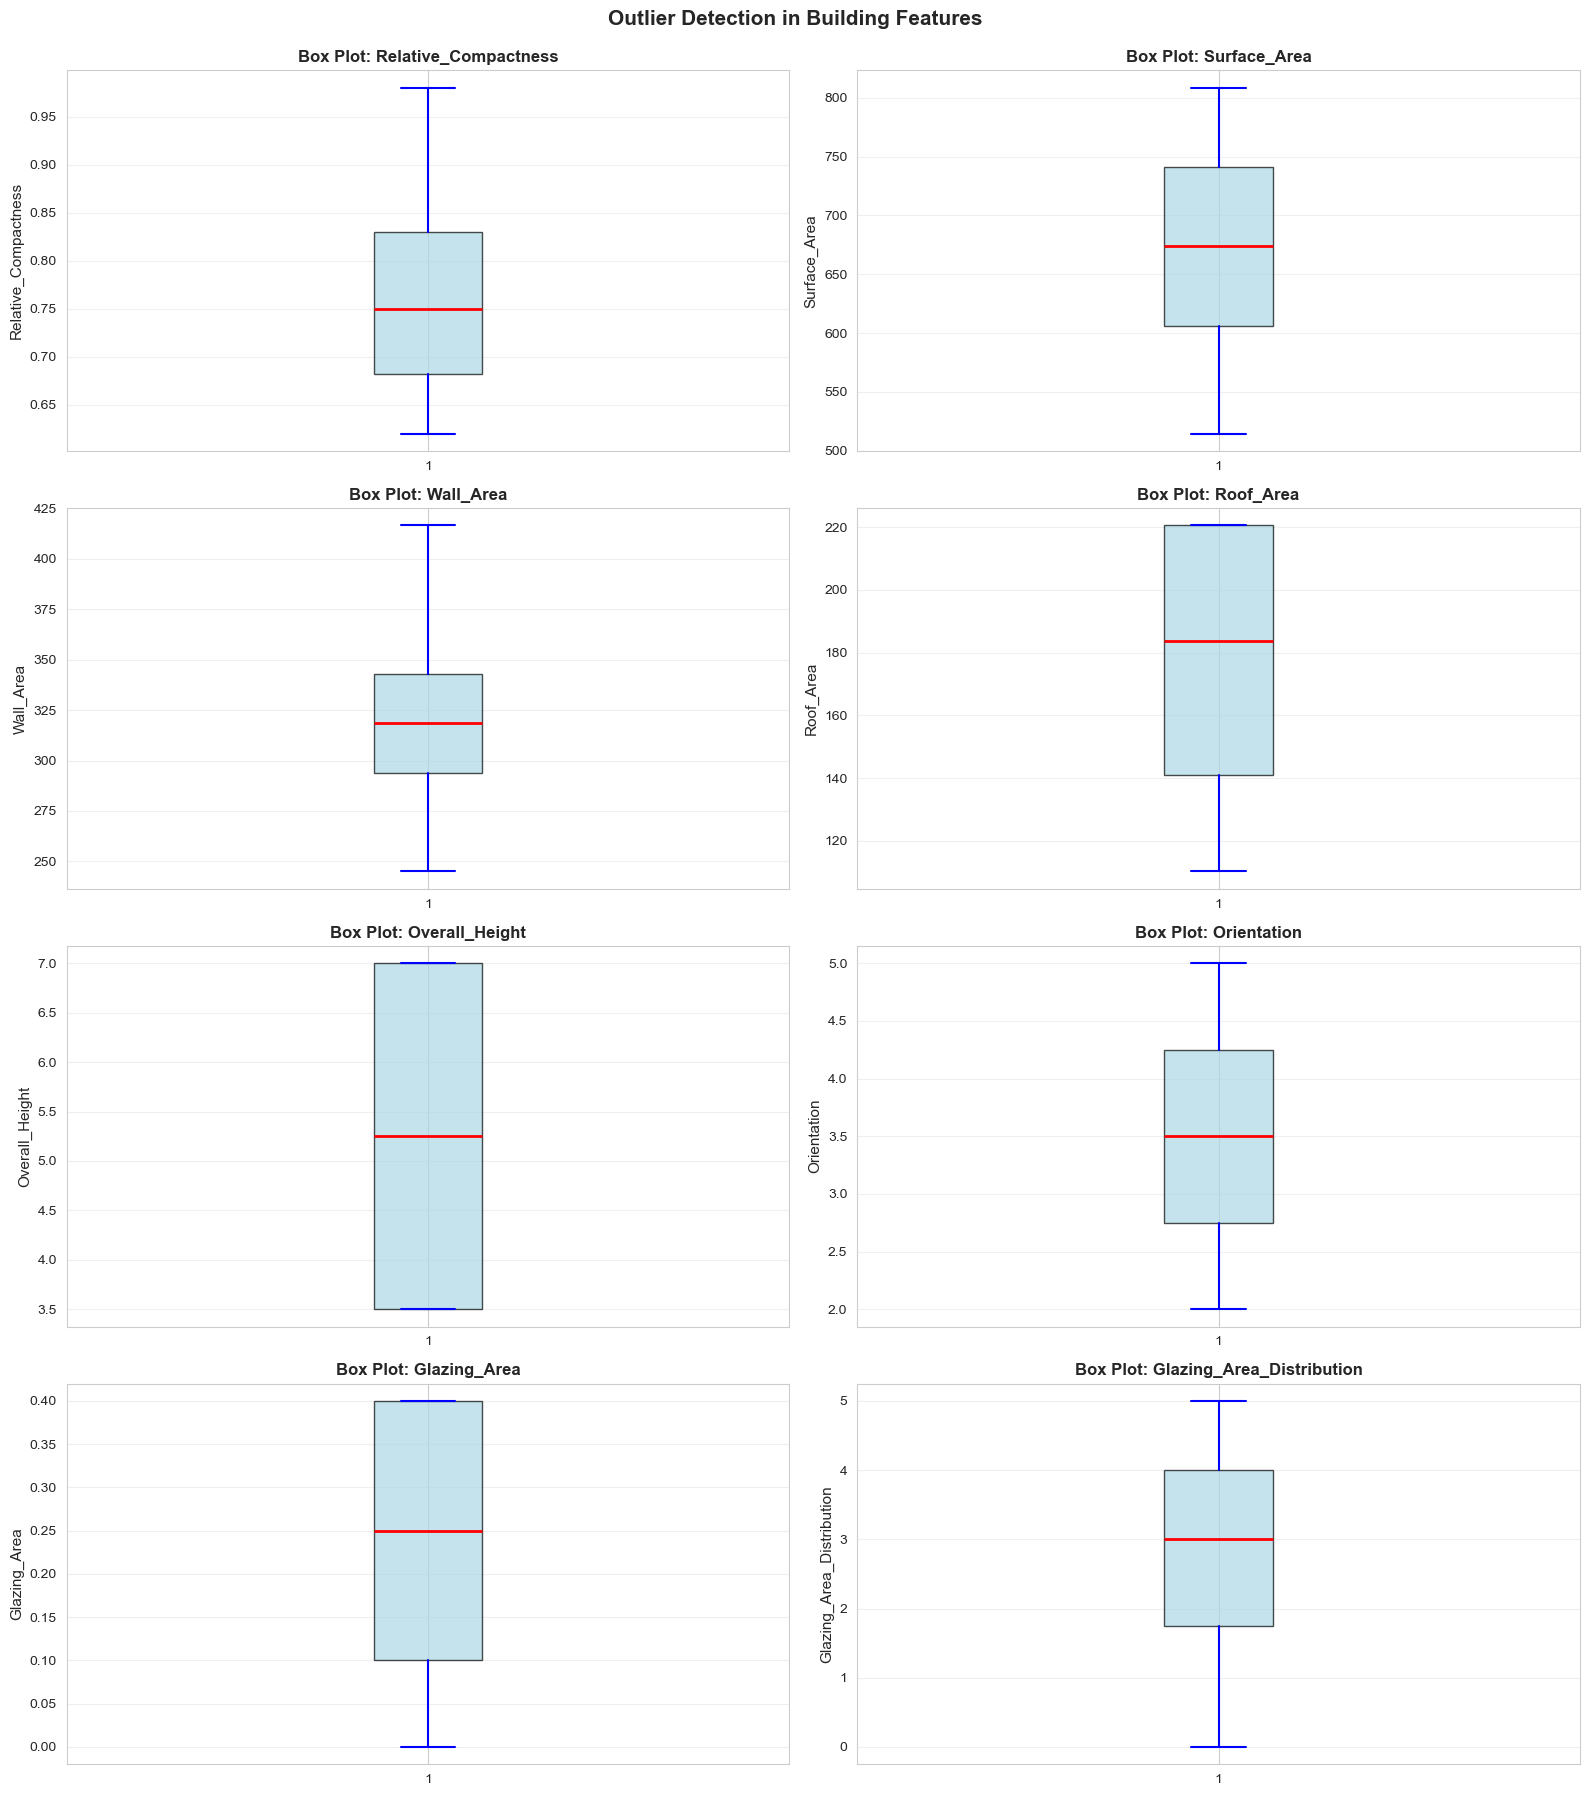

In [192]:
# Box plots for features only (not targets)
fig, axes = plt.subplots(4, 2, figsize=(16, 18))
axes = axes.ravel()

feature_cols = df.columns[:-2]  # Exclude target columns

for idx, col in enumerate(feature_cols):
    bp = axes[idx].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                           boxprops=dict(facecolor='lightblue', alpha=0.7),
                           medianprops=dict(color='red', linewidth=2),
                           whiskerprops=dict(color='blue', linewidth=1.5),
                           capprops=dict(color='blue', linewidth=1.5))
    axes[idx].set_title(f'Box Plot: {col}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel(col, fontsize=11)
    axes[idx].grid(True, alpha=0.3, axis='y')

plt.suptitle('Outlier Detection in Building Features', fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

In [193]:
# Calculate outliers using IQR method for features only
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

print("=" * 90)
print("OUTLIER DETECTION FOR BUILDING FEATURES (IQR Method)")
print("=" * 90)
feature_cols = df.columns[:-2]  # Exclude targets

total_outliers = 0
for col in feature_cols:
    n_outliers, lower, upper = detect_outliers_iqr(df, col)
    total_outliers += n_outliers
    status = "⚠️" if n_outliers > 0 else "✓"
    print(f"{status} {col:35s}: {n_outliers:3d} outliers (valid range: [{lower:.2f}, {upper:.2f}])")
    
print("\n" + "=" * 90)
print(f"Total outliers detected across all features: {total_outliers}")
print("\nNote: We focus on feature outliers for data quality assessment.")
print("Target variables (Heating/Cooling Loads) are not checked as they are our")
print("prediction outputs and should not be filtered.")
print("=" * 90)

OUTLIER DETECTION FOR BUILDING FEATURES (IQR Method)
✓ Relative_Compactness               :   0 outliers (valid range: [0.46, 1.05])
✓ Surface_Area                       :   0 outliers (valid range: [404.25, 943.25])
✓ Wall_Area                          :   0 outliers (valid range: [220.50, 416.50])
✓ Roof_Area                          :   0 outliers (valid range: [21.44, 339.94])
✓ Overall_Height                     :   0 outliers (valid range: [-1.75, 12.25])
✓ Orientation                        :   0 outliers (valid range: [0.50, 6.50])
✓ Glazing_Area                       :   0 outliers (valid range: [-0.35, 0.85])
✓ Glazing_Area_Distribution          :   0 outliers (valid range: [-1.62, 7.38])

Total outliers detected across all features: 0

Note: We focus on feature outliers for data quality assessment.
Target variables (Heating/Cooling Loads) are not checked as they are our
prediction outputs and should not be filtered.


##  Feature Impact Summary Table

In [194]:
# Create a comparison table of feature impacts
feature_impact = pd.DataFrame({
    'Feature': df.columns[:-2],
    'Heating_Load_Corr': [heating_corr[feat] for feat in df.columns[:-2]],
    'Cooling_Load_Corr': [cooling_corr[feat] for feat in df.columns[:-2]],
})

# Add absolute average correlation
feature_impact['Avg_Abs_Correlation'] = (
    feature_impact['Heating_Load_Corr'].abs() + 
    feature_impact['Cooling_Load_Corr'].abs()
) / 2

# Sort by average absolute correlation
feature_impact = feature_impact.sort_values('Avg_Abs_Correlation', ascending=False)

print("=" * 90)
print("FEATURE IMPORTANCE RANKING")
print("=" * 90)
print("\nFeatures ranked by their correlation with both target variables:\n")
display(feature_impact.style.background_gradient(subset=['Heating_Load_Corr', 'Cooling_Load_Corr', 'Avg_Abs_Correlation'], 
                                                  cmap='RdYlGn', vmin=-1, vmax=1))

print("\n" + "=" * 90)
print("KEY INSIGHTS:")
print("=" * 90)
top_3 = feature_impact.head(3)['Feature'].tolist()
print(f"\n✓ Top 3 Most Important Features: {', '.join(top_3)}")
print(f"\n✓ These features have the strongest relationship with energy load requirements")
print(f"  and should be prioritized in predictive modeling.")

# Identify features with different impacts on heating vs cooling
feature_impact['Impact_Difference'] = abs(
    feature_impact['Heating_Load_Corr'] - feature_impact['Cooling_Load_Corr']
)
diff_features = feature_impact.nlargest(2, 'Impact_Difference')['Feature'].tolist()
print(f"\n✓ Features with Different Heating vs Cooling Impact: {', '.join(diff_features)}")
print(f"  These features affect heating and cooling loads differently.")

FEATURE IMPORTANCE RANKING

Features ranked by their correlation with both target variables:



,Feature,Heating_Load_Corr,Cooling_Load_Corr,Avg_Abs_Correlation
4,Overall_Height,0.889431,0.895785,0.892608
3,Roof_Area,-0.861828,-0.862547,0.862187
1,Surface_Area,-0.658120,-0.672999,0.665560
0,Relative_Compactness,0.622272,0.634339,0.628306
2,Wall_Area,0.455671,0.427117,0.441394
6,Glazing_Area,0.269841,0.207505,0.238673
7,Glazing_Area_Distribution,0.087368,0.050525,0.068946
5,Orientation,-0.002587,0.014290,0.008438



KEY INSIGHTS:

✓ Top 3 Most Important Features: Overall_Height, Roof_Area, Surface_Area

✓ These features have the strongest relationship with energy load requirements
  and should be prioritized in predictive modeling.

✓ Features with Different Heating vs Cooling Impact: Glazing_Area, Glazing_Area_Distribution
  These features affect heating and cooling loads differently.
